# Category promotion calendars with terminal washout

The category optimizer chooses 12-week promotion calendars, while all
policies are evaluated through week 18. The six post-decision weeks
contain no new promotions and capture displaced demand that would
otherwise fall outside the objective.

The notebook also compares \(H_w\in\{0,4,6\}\) at
\(\alpha=2.24\) to measure the size of the terminal-horizon correction.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        root
        for root in [
            CURRENT_DIR,
            CURRENT_DIR.parent,
        ]
        if (
            root
            / "data"
            / "processed"
        ).is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate project root from {CURRENT_DIR}"
    )

SRC_DIR = PROJECT_ROOT / "src"

if str(
    SRC_DIR
) not in sys.path:
    sys.path.insert(
        0,
        str(
            SRC_DIR
        ),
    )

from tiny_paper_pipeline_v3 import (
    PlanningConfig,
    SupportedActionConfig,
    build_category_sensitivity_v2,
    build_product_schedule_artifact_v2,
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)
TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)
FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

for directory in [
    PROCESSED_DIR,
    TABLE_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\janza\price-of-extrapolation


In [2]:
ARTIFACT_PATHS = {
    "empirical_w0": (
        PROCESSED_DIR
        / "product_schedule_artifact_empirical_w0.pkl"
    ),
    "empirical_w4": (
        PROCESSED_DIR
        / "product_schedule_artifact_empirical_w4.pkl"
    ),
    "empirical_w6": (
        PROCESSED_DIR
        / "product_schedule_artifact_empirical_w6.pkl"
    ),
    "common_0_30_w6": (
        PROCESSED_DIR
        / "product_schedule_artifact_common_0_30_w6.pkl"
    ),
}

CATEGORY_CALENDAR_PATH = (
    TABLE_DIR
    / "category_capacity_calendars_washout6.csv"
)
CATEGORY_SUMMARY_PATH = (
    TABLE_DIR
    / "category_capacity_summary_washout6.csv"
)
CATEGORY_PRODUCT_PATH = (
    TABLE_DIR
    / "category_capacity_product_values_washout6.csv"
)
CATEGORY_COMPARISON_PATH = (
    TABLE_DIR
    / "category_capacity_comparisons_washout6.csv"
)
WASHOUT_SENSITIVITY_PATH = (
    TABLE_DIR
    / "category_washout_sensitivity.csv"
)

VDO_FIGURE_PATH = (
    FIGURE_DIR
    / "category_VDO_washout6.png"
)
WASHOUT_FIGURE_PATH = (
    FIGURE_DIR
    / "category_terminal_washout_sensitivity.png"
)
ACTIVE_SET_FIGURE_PATH = (
    FIGURE_DIR
    / "category_active_set_changes_washout6.png"
)
CALENDAR_FIGURE_PATH = (
    FIGURE_DIR
    / "empirical_calendar_alpha_2_24_washout6.png"
)

CAPACITIES = (
    1,
    2,
    3,
    8,
)
ALPHA_GRID = np.unique(
    np.round(
        np.concatenate(
            [
                np.arange(
                    1.20,
                    3.20
                    + 0.025,
                    0.05,
                ),
                np.array(
                    [
                        2.24
                    ]
                ),
            ]
        ),
        10,
    )
)

MAIN_ALPHA = 2.24
MAIN_CAPACITY = 2
PRIMARY_GRID = (
    "empirical_w6"
)

## 2. Run the primary capacity-by-contract analysis

In [3]:
required = list(
    ARTIFACT_PATHS.values()
)
missing = [
    path
    for path in (
        required
    )
    if not path.is_file()
]

if missing:
    raise FileNotFoundError(
        "Run notebook 08c first. Missing: "
        + ", ".join(
            str(
                path
            )
            for path in (
                missing
            )
        )
    )

loaded_artifacts = {
    grid_name: pd.read_pickle(
        path
    )
    for grid_name, path in (
        ARTIFACT_PATHS.items()
    )
}

primary_artifacts = {
    "empirical_w6": (
        loaded_artifacts[
            "empirical_w6"
        ]
    ),
    "common_0_30_w6": (
        loaded_artifacts[
            "common_0_30_w6"
        ]
    ),
}

primary_results = (
    build_category_sensitivity_v2(
        artifacts=(
            primary_artifacts
        ),
        alpha_grid=(
            ALPHA_GRID
        ),
        capacities=(
            CAPACITIES
        ),
    )
)

category_calendars = (
    primary_results[
        "calendars"
    ]
)
category_summary = (
    primary_results[
        "summary"
    ]
)
category_product_values = (
    primary_results[
        "product_values"
    ]
)
category_comparisons = (
    primary_results[
        "comparisons"
    ]
)

for frame in [
    category_calendars,
    category_summary,
    category_product_values,
    category_comparisons,
]:
    frame[
        "decision_horizon"
    ] = 12
    frame[
        "washout_horizon"
    ] = 6
    frame[
        "evaluation_horizon"
    ] = 18

display(
    category_comparisons.loc[
        np.isclose(
            category_comparisons[
                "alpha"
            ],
            MAIN_ALPHA,
        )
    ].sort_values(
        [
            "grid_name",
            "weekly_capacity",
        ]
    )
)

,grid_name,weekly_capacity,alpha,value_of_dynamic_optimization,relative_VDO,dynamic_active_product_set,myopic_active_product_set,active_set_changed,active_set_symmetric_difference,product_promotion_count_disagreement,product_week_timing_disagreement,dynamic_binding_weeks,myopic_binding_weeks,dynamic_supported_share,myopic_supported_share,decision_horizon,washout_horizon,evaluation_horizon
189,common_0_30_w6,1,2.24,0.087908,0.000032,1600066510|3800000110|3800000120,1600066510|3800000110|3800000120,False,0,0,16,12,12,0.333333,0.333333,12,6,18
231,common_0_30_w6,2,2.24,0.566385,0.000207,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,8,6,8,0.500000,0.500000,12,6,18
273,common_0_30_w6,3,2.24,0.664652,0.000243,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,16,3,4,0.500000,0.500000,12,6,18
315,common_0_30_w6,8,2.24,0.701544,0.000256,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,16,0,0,0.500000,0.500000,12,6,18
21,empirical_w6,1,2.24,0.000000,0.000000,1600066510|3800000110|3800000120,1600066510|3800000110|3800000120,False,0,0,0,12,12,1.000000,1.000000,12,6,18
63,empirical_w6,2,2.24,0.442364,0.000154,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,12,6,8,1.000000,1.000000,12,6,18
105,empirical_w6,3,2.24,0.506718,0.000177,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,20,2,4,1.000000,1.000000,12,6,18
147,empirical_w6,8,2.24,0.557088,0.000194,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,18,0,0,1.000000,1.000000,12,6,18


## 3. Quantify the terminal-horizon correction

In [4]:
washout_artifacts = {
    grid_name: loaded_artifacts[
        grid_name
    ]
    for grid_name in [
        "empirical_w0",
        "empirical_w4",
        "empirical_w6",
    ]
}

washout_results = (
    build_category_sensitivity_v2(
        artifacts=(
            washout_artifacts
        ),
        alpha_grid=np.array(
            [
                MAIN_ALPHA
            ],
            dtype=float,
        ),
        capacities=(
            CAPACITIES
        ),
    )
)

washout_sensitivity = (
    washout_results[
        "comparisons"
    ]
    .copy()
)
washout_map = {
    "empirical_w0": 0,
    "empirical_w4": 4,
    "empirical_w6": 6,
}
washout_sensitivity[
    "decision_horizon"
] = 12
washout_sensitivity[
    "washout_horizon"
] = (
    washout_sensitivity[
        "grid_name"
    ].map(
        washout_map
    )
)
washout_sensitivity[
    "evaluation_horizon"
] = (
    washout_sensitivity[
        "decision_horizon"
    ]
    + washout_sensitivity[
        "washout_horizon"
    ]
)

no_washout = (
    washout_sensitivity.loc[
        washout_sensitivity[
            "washout_horizon"
        ].eq(
            0
        ),
        [
            "weekly_capacity",
            "value_of_dynamic_optimization",
        ],
    ]
    .rename(
        columns={
            "value_of_dynamic_optimization": (
                "VDO_no_washout"
            )
        }
    )
)

washout_sensitivity = (
    washout_sensitivity.merge(
        no_washout,
        on=(
            "weekly_capacity"
        ),
        how="left",
        validate="many_to_one",
    )
)
washout_sensitivity[
    "VDO_change_from_no_washout"
] = (
    washout_sensitivity[
        "value_of_dynamic_optimization"
    ]
    - washout_sensitivity[
        "VDO_no_washout"
    ]
)

display(
    washout_sensitivity.sort_values(
        [
            "weekly_capacity",
            "washout_horizon",
        ]
    )
)

,grid_name,weekly_capacity,alpha,value_of_dynamic_optimization,relative_VDO,dynamic_active_product_set,myopic_active_product_set,active_set_changed,active_set_symmetric_difference,product_promotion_count_disagreement,product_week_timing_disagreement,dynamic_binding_weeks,myopic_binding_weeks,dynamic_supported_share,myopic_supported_share,decision_horizon,washout_horizon,evaluation_horizon,VDO_no_washout,VDO_change_from_no_washout
0,empirical_w0,1,2.24,1.438650,0.000708,1600066510|3800000110|3800000120,1600066510|3800000110|3800000120,False,0,0,16,12,12,1.0,1.0,12,0,12,1.438650,0.000000
4,empirical_w4,1,2.24,0.000000,0.000000,1600066510|3800000110|3800000120,1600066510|3800000110|3800000120,False,0,0,0,12,12,1.0,1.0,12,4,16,1.438650,-1.438650
8,empirical_w6,1,2.24,0.000000,0.000000,1600066510|3800000110|3800000120,1600066510|3800000110|3800000120,False,0,0,0,12,12,1.0,1.0,12,6,18,1.438650,-1.438650
1,empirical_w0,2,2.24,4.837897,0.002370,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,14,6,8,1.0,1.0,12,0,12,4.837897,0.000000
5,empirical_w4,2,2.24,0.666137,0.000257,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,12,6,8,1.0,1.0,12,4,16,4.837897,-4.171760
9,empirical_w6,2,2.24,0.442364,0.000154,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,12,6,8,1.0,1.0,12,6,18,4.837897,-4.395533
2,empirical_w0,3,2.24,5.576559,0.002732,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,20,2,4,1.0,1.0,12,0,12,5.576559,0.000000
6,empirical_w4,3,2.24,0.762230,0.000294,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,20,2,4,1.0,1.0,12,4,16,5.576559,-4.814329
10,empirical_w6,3,2.24,0.506718,0.000177,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,20,2,4,1.0,1.0,12,6,18,5.576559,-5.069841
3,empirical_w0,8,2.24,6.582763,0.003226,1600066510|3800000110|3800000120|3800000127,1600066510|3800000110|3800000120|3800000127,False,0,0,20,0,0,1.0,1.0,12,0,12,6.582763,0.000000


## 4. Figures

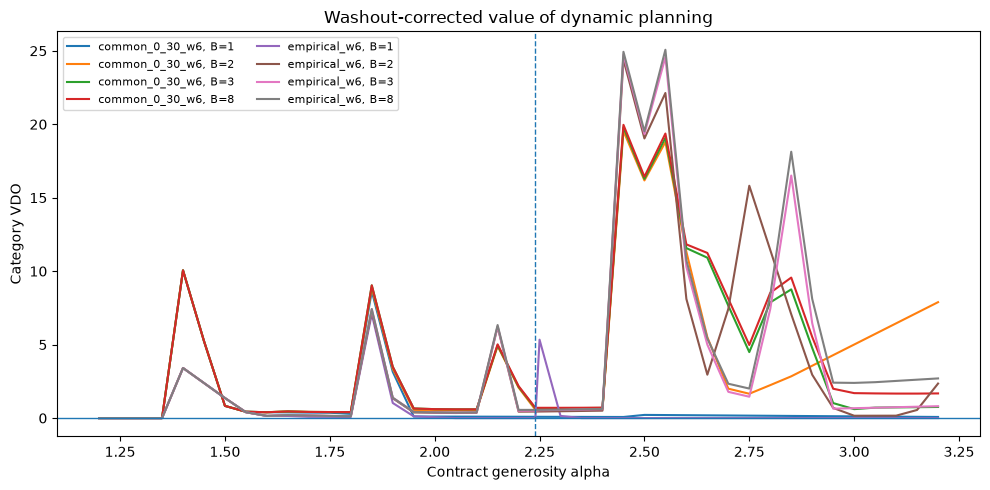

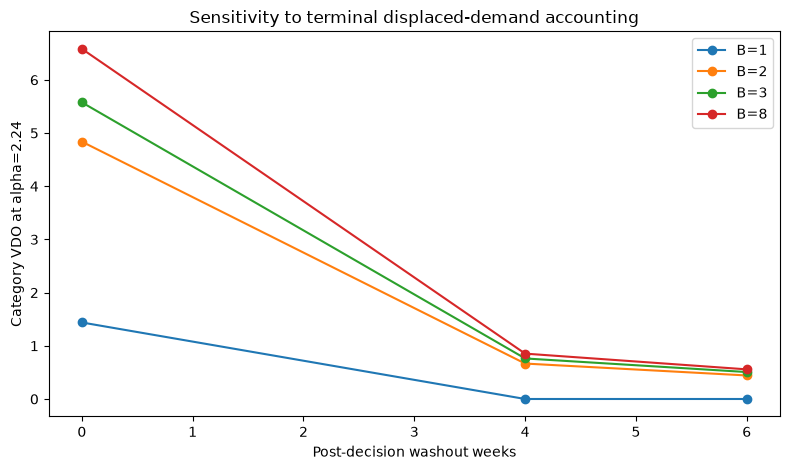

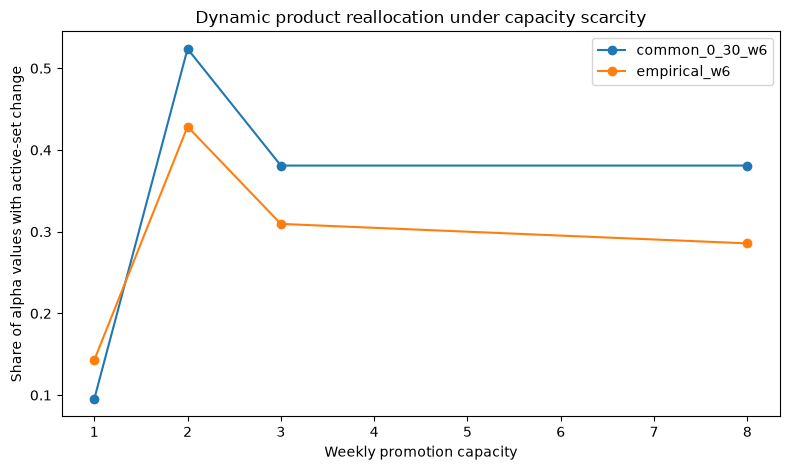

In [5]:
fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)

for (
    grid_name,
    capacity,
), group in (
    category_comparisons.groupby(
        [
            "grid_name",
            "weekly_capacity",
        ],
        observed=True,
    )
):
    ordered = group.sort_values(
        "alpha"
    )
    ax.plot(
        ordered[
            "alpha"
        ],
        ordered[
            "value_of_dynamic_optimization"
        ],
        label=(
            f"{grid_name}, B={capacity}"
        ),
    )

ax.axhline(
    0.0,
    linewidth=1.0,
)
ax.axvline(
    MAIN_ALPHA,
    linestyle="--",
    linewidth=1.0,
)
ax.set_xlabel(
    "Contract generosity alpha"
)
ax.set_ylabel(
    "Category VDO"
)
ax.set_title(
    "Washout-corrected value of dynamic planning"
)
ax.legend(
    fontsize=8,
    ncol=2,
)
fig.tight_layout()
fig.savefig(
    VDO_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(
    figsize=(
        8,
        4.8,
    )
)

for capacity, group in (
    washout_sensitivity.groupby(
        "weekly_capacity",
        observed=True,
    )
):
    ordered = group.sort_values(
        "washout_horizon"
    )
    ax.plot(
        ordered[
            "washout_horizon"
        ],
        ordered[
            "value_of_dynamic_optimization"
        ],
        marker="o",
        label=(
            f"B={capacity}"
        ),
    )

ax.set_xlabel(
    "Post-decision washout weeks"
)
ax.set_ylabel(
    "Category VDO at alpha=2.24"
)
ax.set_title(
    "Sensitivity to terminal displaced-demand accounting"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    WASHOUT_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

active_change = (
    category_comparisons.groupby(
        [
            "grid_name",
            "weekly_capacity",
        ],
        observed=True,
    )[
        "active_set_changed"
    ]
    .mean()
    .rename(
        "active_set_change_share"
    )
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(
        8,
        4.8,
    )
)

for grid_name, group in (
    active_change.groupby(
        "grid_name",
        observed=True,
    )
):
    ordered = group.sort_values(
        "weekly_capacity"
    )
    ax.plot(
        ordered[
            "weekly_capacity"
        ],
        ordered[
            "active_set_change_share"
        ],
        marker="o",
        label=(
            grid_name
        ),
    )

ax.set_xlabel(
    "Weekly promotion capacity"
)
ax.set_ylabel(
    "Share of alpha values with active-set change"
)
ax.set_title(
    "Dynamic product reallocation under capacity scarcity"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    ACTIVE_SET_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 5. Main washout-corrected calendar

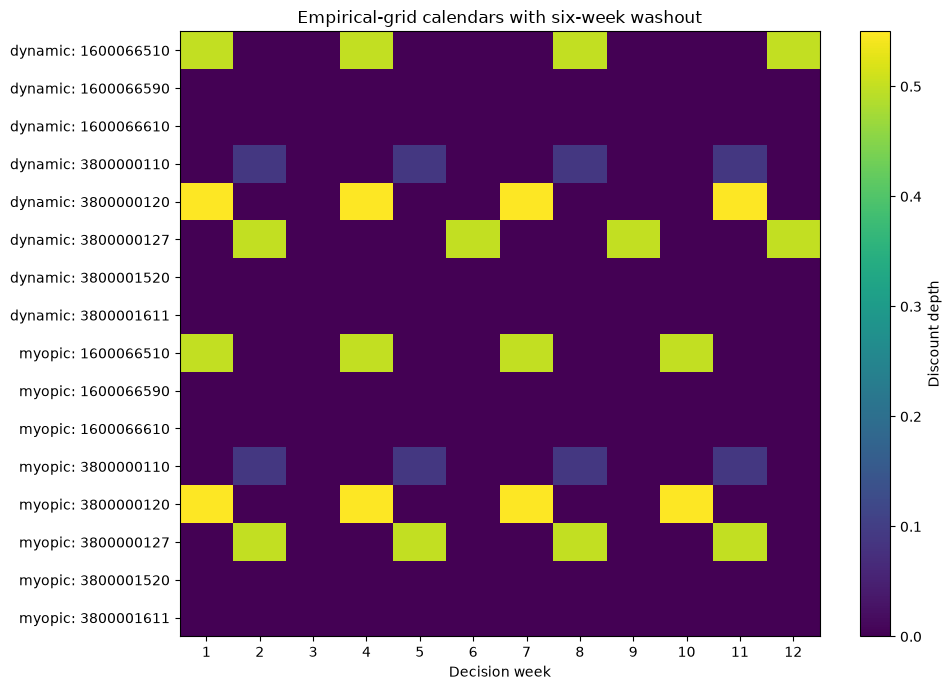

In [6]:
main_calendar = (
    category_calendars.loc[
        category_calendars[
            "grid_name"
        ].eq(
            PRIMARY_GRID
        )
        & category_calendars[
            "weekly_capacity"
        ].eq(
            MAIN_CAPACITY
        )
        & np.isclose(
            category_calendars[
                "alpha"
            ],
            MAIN_ALPHA,
        )
    ]
    .copy()
)

calendar_matrix = (
    main_calendar.pivot_table(
        index=[
            "policy",
            "product_name",
        ],
        columns="week",
        values="discount_depth",
        aggfunc="first",
        fill_value=0.0,
    )
    .sort_index()
)

fig, ax = plt.subplots(
    figsize=(
        10,
        7,
    )
)
image = ax.imshow(
    calendar_matrix.to_numpy(),
    aspect="auto",
)
ax.set_xticks(
    np.arange(
        calendar_matrix.shape[
            1
        ]
    ),
    calendar_matrix.columns,
)
ax.set_yticks(
    np.arange(
        len(
            calendar_matrix
        )
    ),
    [
        f"{policy}: {product}"
        for (
            policy,
            product,
        ) in (
            calendar_matrix.index
        )
    ],
)
ax.set_xlabel(
    "Decision week"
)
ax.set_title(
    "Empirical-grid calendars with six-week washout"
)
fig.colorbar(
    image,
    ax=ax,
    label="Discount depth",
)
fig.tight_layout()
fig.savefig(
    CALENDAR_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 6. Save outputs

In [7]:
category_calendars.to_csv(
    CATEGORY_CALENDAR_PATH,
    index=False,
)
category_summary.to_csv(
    CATEGORY_SUMMARY_PATH,
    index=False,
)
category_product_values.to_csv(
    CATEGORY_PRODUCT_PATH,
    index=False,
)
category_comparisons.to_csv(
    CATEGORY_COMPARISON_PATH,
    index=False,
)
washout_sensitivity.to_csv(
    WASHOUT_SENSITIVITY_PATH,
    index=False,
)

print(
    "Saved washout-corrected comparisons:",
    CATEGORY_COMPARISON_PATH,
)
print(
    "Saved terminal sensitivity:",
    WASHOUT_SENSITIVITY_PATH,
)

Saved washout-corrected comparisons: C:\Users\janza\price-of-extrapolation\results\tables\category_capacity_comparisons_washout6.csv
Saved terminal sensitivity: C:\Users\janza\price-of-extrapolation\results\tables\category_washout_sensitivity.csv


## Interpretation checklist

- The optimizer chooses only the 12 decision-week actions.
- All policies are valued over the same 18-week evaluation horizon.
- The washout period permits no additional promotions.
- Differences between \(H_w=0\) and \(H_w=6\) quantify the original
  terminal-boundary bias.
- Headline policy values should use \(H_w=6\); \(H_w=4\) is a
  robustness specification.